# 07 — User Profile Analysis

**Data source:** `rating.csv` only (20 M rows · userId / movieId / rating / timestamp)

This notebook has two parts:

| Part | Scope | Sections |
|------|-------|----------|
| **A — Population** | All 138 493 users | A1 Activity · A2 Popularity · A3 Rating dist · A4 Temporal · A5 Sparsity |
| **B — Individual** | User 1 vs User 102680 | B1 Volume · B2 Rating dist · B3 Temporal · B4 Popularity · B5 Calibration |

Will add more analysis like Genre (requires `movie.csv`) is deferred to a later notebook.

---
## 0 · Setup & Data Loading

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ── paths ──────────────────────────────────────────────────────────────────
root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

rating_path = root / "data" / "rating.csv"
assert rating_path.exists(), f"Not found: {rating_path}"

# ── global style ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"all": "#4C72B0", "u1": "#DD8452", "u102680": "#55A868"}
USER_IDS = [1, 102680]

# ── load ───────────────────────────────────────────────────────────────────
print("Loading rating.csv … (20 M rows, may take ~10 s)")
df = pd.read_csv(
    rating_path,
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    parse_dates=["timestamp"],
)
print(f"  rows : {len(df):,}")
print(f"  users: {df['userId'].nunique():,}")
print(f"  movies: {df['movieId'].nunique():,}")
df.head(3)

Loading rating.csv … (20 M rows, may take ~10 s)
  rows : 20,000,263
  users: 138,493
  movies: 26,744


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39


---
# Part A — User View
---

## A1 · User Activity Distribution

How many movies has each user rated?  
The distribution reveals the long-tail structure of user engagement.

,value,userId
statistic,,
min,20.00000,36
median,68.00000,666
P50,68.00000,666
P75,155.00000,490
P90,334.00000,2241
P95,520.00000,3295
P99,1113.08000,27463
max,9254.00000,118205
mean,144.41353,1250



User 1      : 175 ratings
User 102680 : 1865 ratings


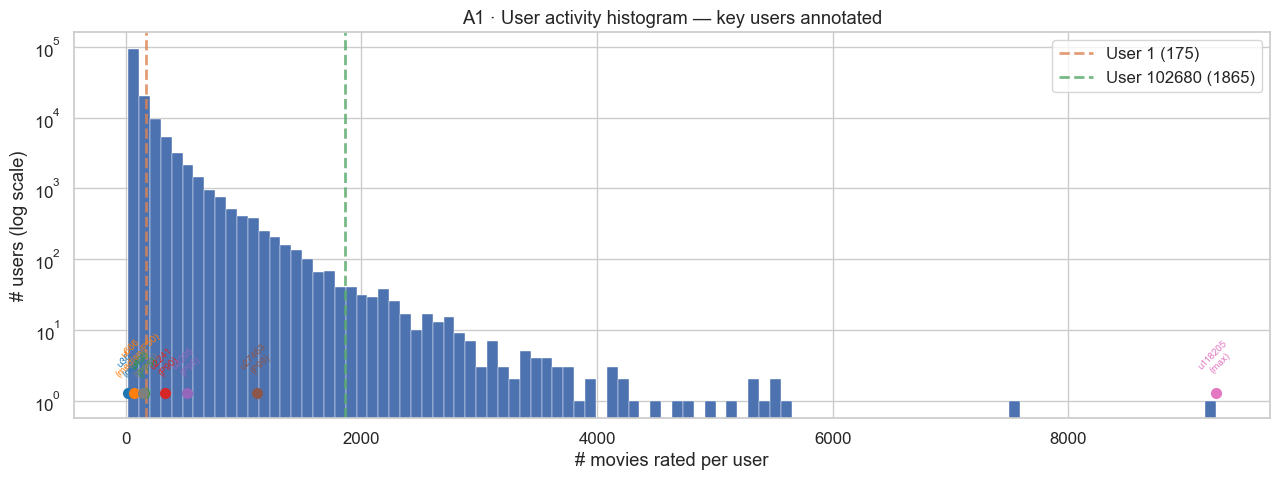

In [3]:
user_counts = df.groupby("userId")["movieId"].count().rename("n_rated")

def nearest_user(target_val):
    """Return the userId whose rating count is closest to target_val."""
    idx = (user_counts - target_val).abs().idxmin()
    return int(idx)

pcts = [50, 75, 90, 95, 99]
rows = []
for label, val in [
    ("min",    float(user_counts.min())),
    ("median", float(user_counts.median())),
    *[(f"P{p}", float(user_counts.quantile(p/100))) for p in pcts],
    ("max",    float(user_counts.max())),
    ("mean",   float(user_counts.mean())),
]:
    uid = nearest_user(val)
    rows.append({"statistic": label, "value": val, "userId": uid})

stats_df = pd.DataFrame(rows).set_index("statistic")
display(stats_df)
print(f"\nUser 1      : {user_counts.get(1, 'N/A')} ratings")
print(f"User 102680 : {user_counts.get(102680, 'N/A')} ratings")

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(user_counts, bins=100, color=COLORS["all"], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("# movies rated per user")
ax.set_ylabel("# users (log scale)")
ax.set_title("A1 · User activity histogram — key users annotated")

# ── stats table users — plot as dots on the x-axis ───────────────────────
# deduplicate by (userId, n_rated) so median==P50 only draws once
seen = set()
stat_markers = []
for row in rows:
    uid  = row["userId"]
    n    = int(user_counts[uid])
    stat = row["statistic"]
    key  = (uid, n)
    if key not in seen:
        stat_markers.append((uid, n, stat))
        seen.add(key)
    else:
        for i, (u, nv, s) in enumerate(stat_markers):
            if (u, nv) == key:
                stat_markers[i] = (u, nv, s + "/" + stat)
                break

cmap = plt.cm.tab10
dot_y = 1.3   # just above the x-axis (log scale starts near 1)

for i, (uid, n, stat) in enumerate(stat_markers):
    color = cmap(i % 10)
    ax.plot(n, dot_y, "o", color=color, markersize=7, zorder=5)
    ax.annotate(f"u{uid}\n({stat})",
                xy=(n, dot_y), xytext=(0, 10),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=7, color=color,
                rotation=45)

# ── highlight the two focus users ─────────────────────────────────────────
for uid, col, lbl in [(1, COLORS["u1"], "User 1"),
                      (102680, COLORS["u102680"], "User 102680")]:
    n = user_counts.get(uid, 0)
    ax.axvline(n, color=col, lw=2, linestyle="--", label=f"{lbl} ({n})", alpha=0.8)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## A2 · Top 10 most active users

In [4]:
# ── Find the top-10 most active users ────────────────────────────────────
TOTAL_MOVIES = df["movieId"].nunique()

top10_users = user_counts.nlargest(10).reset_index()
top10_users.columns = ["userId", "n_rated"]
# coverage_% = movies rated by this user / total movies in catalog × 100
# A typical user covers only ~0.25% of the catalog — the root cause of extreme matrix sparsity.
top10_users["coverage_%"] = (top10_users["n_rated"] / TOTAL_MOVIES * 100).round(2)
top10_users["mean_rating"] = top10_users["userId"].map(
    df.groupby("userId")["rating"].mean().round(3)
)
top10_users.index += 1  # rank from 1
top10_users.index.name = "rank"
print("Top 10 most active users:")
print(f"  (coverage_% = movies rated / {TOTAL_MOVIES:,} total movies in catalog × 100;"
      f"  median user covers only ~{(user_counts.median() / TOTAL_MOVIES * 100):.2f}% — extreme sparsity)")
display(top10_users)

# ── Highlight the #1 user ─────────────────────────────────────────────────
superuser_id   = int(user_counts.idxmax())
superuser_n    = int(user_counts.max())
superuser_cov  = superuser_n / TOTAL_MOVIES * 100
superuser_mean = df[df["userId"] == superuser_id]["rating"].mean()


# print(f"\n★  #1 most active user")
# print(f"   userId       : {superuser_id}")
# print(f"   Movies rated : {superuser_n:,}  ({superuser_cov:.1f}% of full catalog)")
# print(f"   Mean rating  : {superuser_mean:.3f}")
# print(f"\n   Compare:")
# print(f"   User 1      → {user_counts.get(1, 0):,} ratings ({user_counts.get(1, 0)/TOTAL_MOVIES*100:.2f}%)")
# print(f"   User 102680 → {user_counts.get(102680, 0):,} ratings ({user_counts.get(102680, 0)/TOTAL_MOVIES*100:.2f}%)")
# print(f"   User {superuser_id} (★) → {superuser_n:,} ratings ({superuser_cov:.2f}%)")

Top 10 most active users:
  (coverage_% = movies rated / 26,744 total movies in catalog × 100;  median user covers only ~0.25% — extreme sparsity)


,userId,n_rated,coverage_%,mean_rating
rank,,,,
1,118205,9254,34.60,3.279
2,8405,7515,28.10,3.208
3,82418,5646,21.11,3.517
4,121535,5520,20.64,2.793
5,125794,5491,20.53,3.763
6,74142,5447,20.37,1.577
7,34576,5356,20.03,3.012
8,131904,5330,19.93,3.249
9,83090,5169,19.33,2.405


## A3 · Global Rating Distribution

What does the 0.5 – 5.0 scale look like across all 20 M ratings?  
Are users generally generous? Do they prefer whole numbers?

Global mean  : 3.526
Global median: 3.5
Half-step ratings (x.5): 25.7% of all ratings
Whole-step ratings (x.0): 74.3% of all ratings


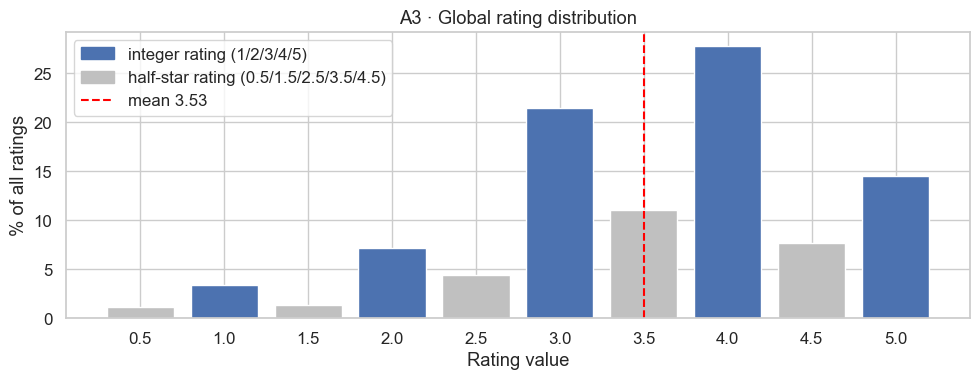

In [5]:
rating_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
counts = df["rating"].value_counts().reindex(rating_vals, fill_value=0)
pcts_r = counts / counts.sum() * 100

global_mean = df["rating"].mean()
global_median = df["rating"].median()
print(f"Global mean  : {global_mean:.3f}")
print(f"Global median: {global_median:.1f}")
print(f"Half-step ratings (x.5): {pcts_r[[0.5,1.5,2.5,3.5,4.5]].sum():.1f}% of all ratings")
print(f"Whole-step ratings (x.0): {pcts_r[[1.0,2.0,3.0,4.0,5.0]].sum():.1f}% of all ratings")

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#c0c0c0" if v % 1 != 0 else COLORS["all"] for v in rating_vals]
ax.bar([str(v) for v in rating_vals], pcts_r.values, color=bar_colors, edgecolor="white")
ax.legend(handles=[
    Patch(color=COLORS["all"], label="integer rating (1/2/3/4/5)"),
    Patch(color="#c0c0c0", label="half-star rating (0.5/1.5/2.5/3.5/4.5)"),
    plt.Line2D([0],[0], color="red", linestyle="--", label=f"mean {global_mean:.2f}"),
])
ax.axvline(str(round(global_mean * 2) / 2), color="red", lw=1.5, linestyle="--")
ax.set_xlabel("Rating value")
ax.set_ylabel("% of all ratings")
ax.set_title("A3 · Global rating distribution")
plt.tight_layout()
plt.show()

## A4 · Temporal Trend (1995 – 2015)

When were ratings submitted? Are there activity peaks?  
Did average ratings shift over time?

Peak year: 2000  —  1,953,659 ratings  (15,004 active users)


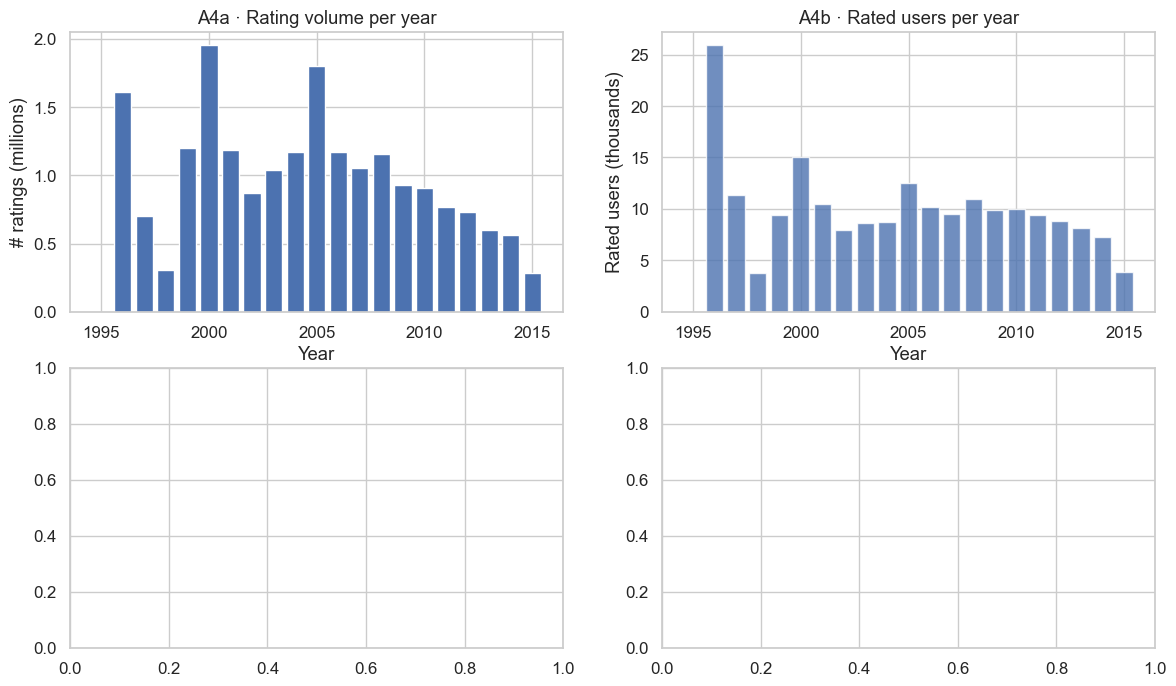

In [6]:
# ensure datetime
if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.to_period("M")

yearly = df.groupby("year").agg(
    n_ratings=("rating", "count"),
    mean_rating=("rating", "mean"),
    n_users=("userId", "nunique"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# A4a: ratings volume per year
ax = axes[0, 0]
ax.bar(yearly["year"], yearly["n_ratings"] / 1e6, color=COLORS["all"])
ax.set_xlabel("Year")
ax.set_ylabel("# ratings (millions)")
ax.set_title("A4a · Rating volume per year")

# A4b: rated users per year
ax = axes[0, 1]
ax.bar(yearly["year"], yearly["n_users"] / 1e3, color=COLORS["all"], alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Rated users (thousands)")
ax.set_title("A4b · Rated users per year")



peak = yearly.loc[yearly["n_ratings"].idxmax()]
print(f"Peak year: {int(peak['year'])}  —  {peak['n_ratings']:,.0f} ratings  ({peak['n_users']:,.0f} active users)")

## A5 · Sparsity Overview

The user-item rating matrix has ~138 K rows × ~27 K columns.  
Only a tiny fraction of cells are filled — this sparsity is what makes RBM reconstruction non-trivial.

Users         :    138,493
Movies        :     26,744
Total cells   : 3,703,856,792
Observed ratings: 20,000,263
Fill rate     :      0.540%
Sparsity      :     99.460%

Per-user coverage (% of movies rated):
  median : 0.254%
  P99    : 4.16%
  User 1 : 0.654%
  User 102680: 6.974%


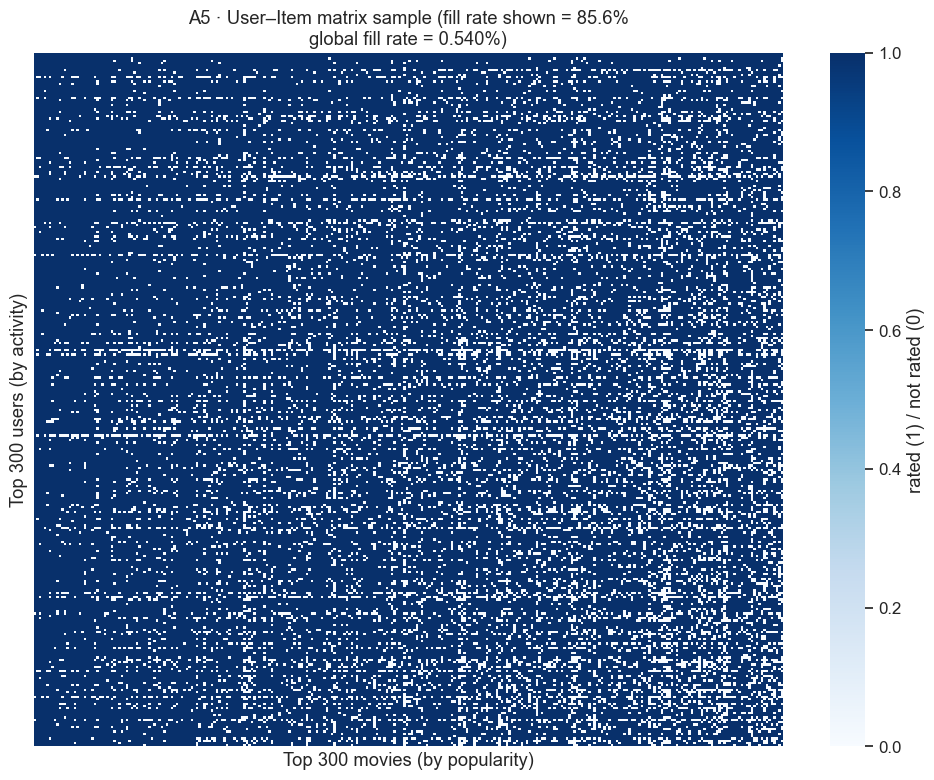

In [7]:
if "movie_counts" not in dir():
    movie_counts = df.groupby("movieId")["userId"].count().rename("n_raters")

n_users  = df["userId"].nunique()
n_movies = df["movieId"].nunique()
n_ratings = len(df)
total_cells = n_users * n_movies
fill_rate = n_ratings / total_cells * 100

print(f"Users         : {n_users:>10,}")
print(f"Movies        : {n_movies:>10,}")
print(f"Total cells   : {total_cells:>10,}")
print(f"Observed ratings: {n_ratings:>8,}")
print(f"Fill rate     : {fill_rate:>10.3f}%")
print(f"Sparsity      : {100-fill_rate:>10.3f}%")

# Per-user sparsity stats
user_fill = (user_counts / n_movies * 100)
print(f"\nPer-user coverage (% of movies rated):")
print(f"  median : {user_fill.median():.3f}%")
print(f"  P99    : {user_fill.quantile(0.99):.2f}%")
print(f"  User 1 : {user_fill.get(1, 0):.3f}%")
print(f"  User 102680: {user_fill.get(102680, 0):.3f}%")

# Visualise: sample of the matrix as a heatmap
SAMPLE_USERS  = 300
SAMPLE_MOVIES = 300

# pick top-N most active users and top-N most popular movies for visibility
top_users  = user_counts.nlargest(SAMPLE_USERS).index
top_movies = movie_counts.nlargest(SAMPLE_MOVIES).index

sub = df[df["userId"].isin(top_users) & df["movieId"].isin(top_movies)]
mat = sub.pivot_table(index="userId", columns="movieId", values="rating", fill_value=0)
# reindex to enforce dimensions
mat = mat.reindex(index=top_users, columns=top_movies, fill_value=0)
presence = (mat > 0).astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    presence,
    ax=ax,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "rated (1) / not rated (0)"},
)
ax.set_xlabel(f"Top {SAMPLE_MOVIES} movies (by popularity)")
ax.set_ylabel(f"Top {SAMPLE_USERS} users (by activity)")
fill_sub = presence.values.mean() * 100
ax.set_title(
    f"A5 · User–Item matrix sample (fill rate shown = {fill_sub:.1f}%\n"
    f"global fill rate = {fill_rate:.3f}%)"
)
plt.tight_layout()
plt.show()

## A6 · User Rating Archetypes

Using **mean** (optimism) and **std dev** (spread) simultaneously, we identify four archetypal rating styles and surface a representative userId for each.

| Archetype | Signature |
|---|---|
| **Optimist** | high mean, low std — almost always rates 4 or 5 |
| **Critic** | low mean, low std — consistently harsh |
| **Polarized** | high std — loves or hates, rarely in between |
| **Consistent moderate** | mean near global average, lowest std — very predictable |


Representative userId per archetype:


/var/folders/8l/bqykkvkj5vz4ffw8hmxk7p1w0000gn/T/ipykernel_14730/3062944009.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_profile["entropy"] = df.groupby("userId").apply(_entropy)


,userId,n_rated,mean,std,entropy (bits)
archetype,,,,,
Optimist,138325,1700,4.361,0.645,2.035
Critic,83090,5169,2.405,0.688,1.408
Polarized,30874,58,2.914,2.256,1.103
Consistent,26480,1174,3.508,0.365,1.535



  [Optimist]  userId 138325  —  Rates almost everything highly (avg 4.36/5). Spread is narrow (std 0.65) — genuinely likes most movies.
  [Critic]  userId 83090  —  Consistently low scores (avg 2.4/5, std 0.69). Hard to please — rarely gives more than 3 stars.
  [Polarized]  userId 30874  —  Extreme ratings only (std 2.26, the highest in the dataset). Either loves it or hates it — almost never rates in the middle.
  [Consistent]  userId 26480  —  Avg 3.51/5, std just 0.37 — ratings cluster tightly around the global mean. Almost every score falls within a narrow band, across all 1,174 movies rated.


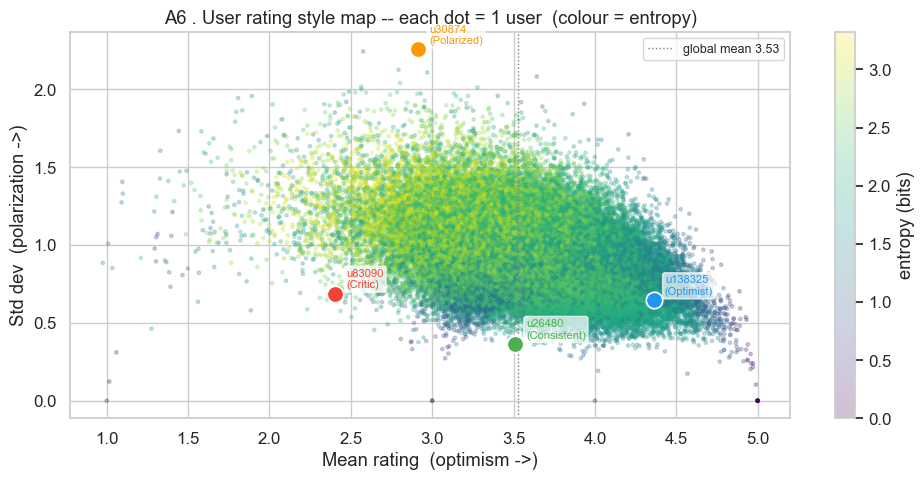

In [20]:
from scipy.stats import entropy as sp_entropy

# ── Per-user stats (min 50 ratings for reliable estimates) ───────────────
MIN_N = 50

def _entropy(group):
    counts = group["rating"].value_counts()
    probs  = counts / counts.sum()
    return float(sp_entropy(probs.values, base=2))

user_profile = (
    df.groupby("userId")["rating"]
    .agg(mean="mean", std="std", n="count")
    .query("n >= @MIN_N")
    .copy()
)
user_profile["entropy"] = df.groupby("userId").apply(_entropy)
user_profile = user_profile.dropna()

# ── Identify archetypes ───────────────────────────────────────────────────
p95_mean = user_profile["mean"].quantile(0.95)
p05_mean = user_profile["mean"].quantile(0.05)
p25_std  = user_profile["std"].quantile(0.25)
gm       = df["rating"].mean()

opt_pool  = user_profile[(user_profile["mean"] >= p95_mean) & (user_profile["std"] <= p25_std)]
crit_pool = user_profile[(user_profile["mean"] <= p05_mean) & (user_profile["std"] <= p25_std)]
mod_pool  = user_profile[user_profile["mean"].between(gm - 0.1, gm + 0.1)]

optimist_id   = int(opt_pool.nlargest(1, "n").index[0])  if len(opt_pool)  else int(user_profile["mean"].idxmax())
critic_id     = int(crit_pool.nlargest(1, "n").index[0]) if len(crit_pool) else int(user_profile["mean"].idxmin())
polarized_id  = int(user_profile["std"].idxmax())
consistent_id = int(mod_pool["std"].idxmin()) if len(mod_pool) else int(user_profile["std"].idxmin())

archetypes = {
    "Optimist":   optimist_id,
    "Critic":     critic_id,
    "Polarized":  polarized_id,
    "Consistent": consistent_id,
}

# ── Summary table with plain-language description ─────────────────────────
def describe(label, uid):
    r = user_profile.loc[uid]
    m, s, e, n = round(r["mean"], 2), round(r["std"], 2), round(r["entropy"], 2), int(r["n"])
    if label == "Optimist":
        return (f"Rates almost everything highly (avg {m}/5). "
                f"Spread is narrow (std {s}) — genuinely likes most movies.")
    elif label == "Critic":
        return (f"Consistently low scores (avg {m}/5, std {s}). "
                f"Hard to please — rarely gives more than 3 stars.")
    elif label == "Polarized":
        return (f"Extreme ratings only (std {s}, the highest in the dataset). "
                f"Either loves it or hates it — almost never rates in the middle.")
    else:
        return (f"Avg {m}/5, std just {s} — ratings cluster tightly around the global mean. "
                f"Almost every score falls within a narrow band, across all {n:,} movies rated.")

rows = []
for label, uid in archetypes.items():
    r = user_profile.loc[uid]
    rows.append({"archetype": label, "userId": uid,
                 "n_rated": int(r["n"]), "mean": round(r["mean"], 3),
                 "std": round(r["std"], 3), "entropy (bits)": round(r["entropy"], 3)})
print("Representative userId per archetype:")
display(pd.DataFrame(rows).set_index("archetype"))

print()
for label, uid in archetypes.items():
    print(f"  [{label}]  userId {uid}  —  {describe(label, uid)}")

# ── Scatter: mean vs std, colour = entropy ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    user_profile["mean"], user_profile["std"],
    c=user_profile["entropy"], cmap="viridis",
    alpha=0.25, s=6, rasterized=True
)
plt.colorbar(sc, ax=ax, label="entropy (bits)")

arch_colors = ["#2196F3", "#F44336", "#FF9800", "#4CAF50"]
for (label, uid), col in zip(archetypes.items(), arch_colors):
    r = user_profile.loc[uid]
    ax.scatter(r["mean"], r["std"], color=col, s=140, zorder=6,
               edgecolors="white", linewidths=1.2)
    ax.annotate(f"u{uid}\n({label})",
                xy=(r["mean"], r["std"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=8, color=col,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.axvline(gm, color="grey", lw=1, linestyle=":", label=f"global mean {gm:.2f}")
ax.set_xlabel("Mean rating  (optimism ->)")
ax.set_ylabel("Std dev  (polarization ->)")
ax.set_title("A6 . User rating style map -- each dot = 1 user  (colour = entropy)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
# Part B — Movie View
---

## B1 · Movie Popularity — Long Tail

How many users have rated each movie?  
Classic power-law: a few blockbusters dominate, most movies are rarely seen.

Movies rated by at least N users:
  ≥    1 raters: 26,744 movies  (100.0%)
  ≥    5 raters: 18,345 movies  (68.6%)
  ≥   10 raters: 15,451 movies  (57.8%)
  ≥   50 raters: 10,524 movies  (39.4%)
  ≥  100 raters:  8,546 movies  (32.0%)
  ≥  500 raters:  4,489 movies  (16.8%)


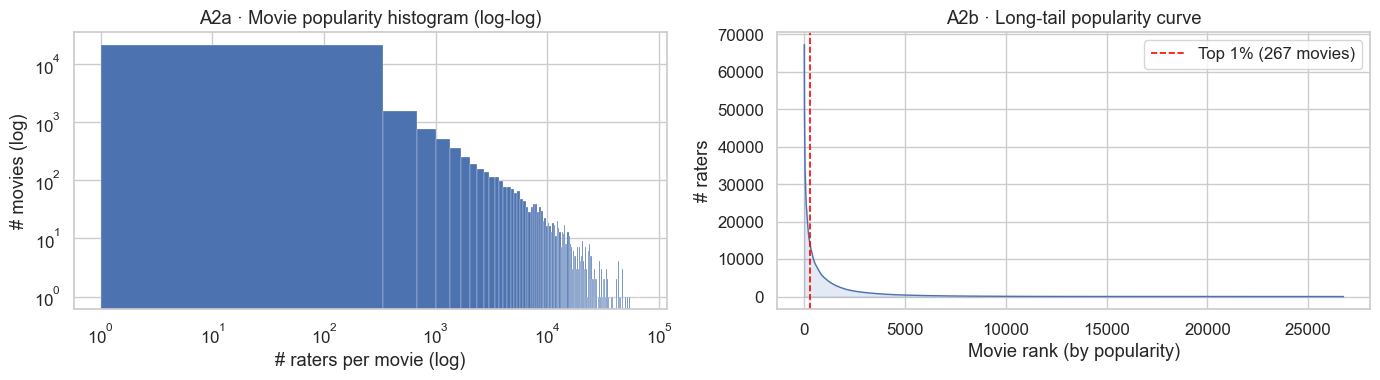


Top 10 most-rated movies (movieId | # raters):
movieId
296     67310
356     66172
318     63366
593     63299
480     59715
260     54502
110     53769
589     52244
2571    51334
527     50054


In [9]:
movie_counts = df.groupby("movieId")["userId"].count().rename("n_raters")
total_movies_in_db = df["movieId"].nunique()

thresholds = [1, 5, 10, 50, 100, 500]
print("Movies rated by at least N users:")
for t in thresholds:
    n = (movie_counts >= t).sum()
    print(f"  ≥ {t:>4} raters: {n:>6,} movies  ({n/total_movies_in_db*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: histogram of rater counts (log-log)
ax = axes[0]
ax.hist(movie_counts, bins=200, color=COLORS["all"], edgecolor="white", linewidth=0.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("# raters per movie (log)")
ax.set_ylabel("# movies (log)")
ax.set_title("A2a · Movie popularity histogram (log-log)")

# right: sorted popularity curve (long tail)
ax2 = axes[1]
sorted_pop = np.sort(movie_counts.values)[::-1]
ax2.plot(range(1, len(sorted_pop)+1), sorted_pop, color=COLORS["all"], lw=1)
ax2.fill_between(range(1, len(sorted_pop)+1), sorted_pop, alpha=0.15, color=COLORS["all"])
ax2.set_xlabel("Movie rank (by popularity)")
ax2.set_ylabel("# raters")
ax2.set_title("A2b · Long-tail popularity curve")
# annotate top-1% cutoff
cutoff = int(len(sorted_pop) * 0.01)
ax2.axvline(cutoff, color="red", lw=1.2, linestyle="--", label=f"Top 1% ({cutoff} movies)")
ax2.legend()

plt.tight_layout()
plt.show()

# Top-10 most rated movies
print("\nTop 10 most-rated movies (movieId | # raters):")
print(movie_counts.sort_values(ascending=False).head(10).to_string())

---
# Part C — Individual User Deep Dive: User TBD
---

In [10]:
u1    = df[df["userId"] == 1].copy()
u2    = df[df["userId"] == 102680].copy()

# ensure datetime on subsets
for u in [u1, u2]:
    if not pd.api.types.is_datetime64_any_dtype(u["timestamp"]):
        u["timestamp"] = pd.to_datetime(u["timestamp"], unit="s", errors="coerce")

TOTAL_MOVIES = df["movieId"].nunique()

print(f"User 1      : {len(u1):,} ratings  |  {TOTAL_MOVIES - len(u1):,} unseen movies")
print(f"User 102680 : {len(u2):,} ratings  |  {TOTAL_MOVIES - len(u2):,} unseen movies")

User 1      : 175 ratings  |  26,569 unseen movies
User 102680 : 1,865 ratings  |  24,879 unseen movies


## C1 · Volume & Coverage

Where do each user sit in the overall activity distribution?

,User 1,User 102680
Metric,,
Rated movies,175,1865
Unseen movies,26569,24879
Coverage (%),0.65%,6.97%
Percentile in all users,77.9th,99.8th


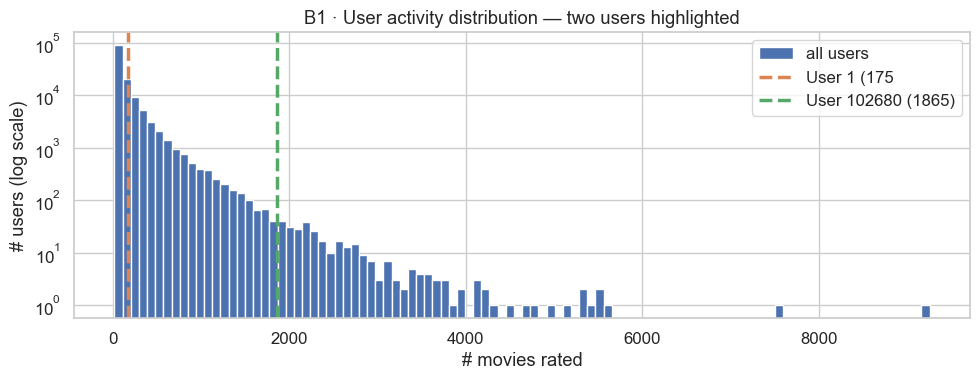

In [11]:
summary = pd.DataFrame({
    "Metric": ["Rated movies", "Unseen movies", "Coverage (%)", "Percentile in all users"],
    "User 1": [
        len(u1),
        TOTAL_MOVIES - len(u1),
        f"{len(u1)/TOTAL_MOVIES*100:.2f}%",
        f"{(user_counts < len(u1)).mean()*100:.1f}th",
    ],
    "User 102680": [
        len(u2),
        TOTAL_MOVIES - len(u2),
        f"{len(u2)/TOTAL_MOVIES*100:.2f}%",
        f"{(user_counts < len(u2)).mean()*100:.1f}th",
    ],
})
display(summary.set_index("Metric"))

# place on activity histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_counts, bins=100, color=COLORS["all"], edgecolor="white", lw=0.3, label="all users")
ax.set_yscale("log")
ax.axvline(len(u1),  color=COLORS["u1"],     lw=2.5, linestyle="--", label=f"User 1 ({len(u1)}")
ax.axvline(len(u2),  color=COLORS["u102680"], lw=2.5, linestyle="--", label=f"User 102680 ({len(u2)})")
ax.set_xlabel("# movies rated")
ax.set_ylabel("# users (log scale)")
ax.set_title("B1 · User activity distribution — two users highlighted")
ax.legend()
plt.tight_layout()
plt.show()

## C2 · Rating Distribution

Are they generous raters or harsh critics?  
Do they prefer whole stars or use half-star granularity?

,User 1,User 102680,Global
Mean,3.743,3.323,3.526
Median,4.000,4.000,3.500
Std dev,0.382,1.358,1.052
Half-star usage (%),43.429,0.054,25.683


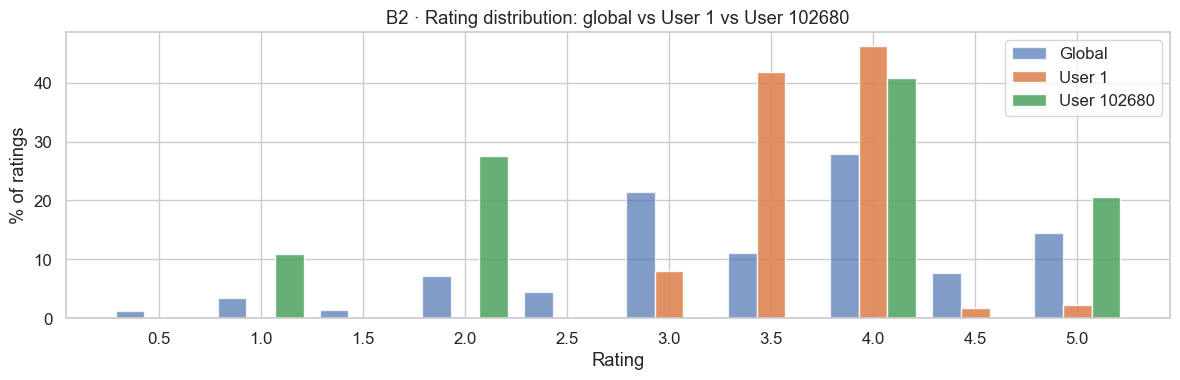

In [12]:
rating_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

def rating_pcts(user_df):
    c = user_df["rating"].value_counts().reindex(rating_vals, fill_value=0)
    return c / c.sum() * 100

pct_u1 = rating_pcts(u1)
pct_u2 = rating_pcts(u2)
pct_all = df["rating"].value_counts().reindex(rating_vals, fill_value=0)
pct_all = pct_all / pct_all.sum() * 100

stats_b2 = pd.DataFrame({
    "User 1"     : [u1["rating"].mean(), u1["rating"].median(), u1["rating"].std(),
                    (u1["rating"] % 1 != 0).mean()*100],
    "User 102680": [u2["rating"].mean(), u2["rating"].median(), u2["rating"].std(),
                    (u2["rating"] % 1 != 0).mean()*100],
    "Global"     : [df["rating"].mean(), df["rating"].median(), df["rating"].std(),
                    (df["rating"] % 1 != 0).mean()*100],
}, index=["Mean", "Median", "Std dev", "Half-star usage (%)"])
display(stats_b2.round(3))

x = np.arange(len(rating_vals))
w = 0.28
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w,   pct_all.values, w, label="Global",      color=COLORS["all"],     alpha=0.7)
ax.bar(x,       pct_u1.values,  w, label="User 1",      color=COLORS["u1"],      alpha=0.9)
ax.bar(x + w,   pct_u2.values,  w, label="User 102680", color=COLORS["u102680"], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in rating_vals])
ax.set_xlabel("Rating")
ax.set_ylabel("% of ratings")
ax.set_title("B2 · Rating distribution: global vs User 1 vs User 102680")
ax.legend()
plt.tight_layout()
plt.show()

## C3 · Temporal Behavior

When did each user rate movies?  
Burst rater (binge session) vs steady rater (distributed over time)?


User 1:
  First rating : 2004-09-10
  Last  rating : 2005-04-02
  Span         : 204 days (0.6 years)
  Avg rate     : 25.7 ratings/month

User 102680:
  First rating : 1999-10-30
  Last  rating : 2015-03-29
  Span         : 5628 days (15.4 years)
  Avg rate     : 9.9 ratings/month


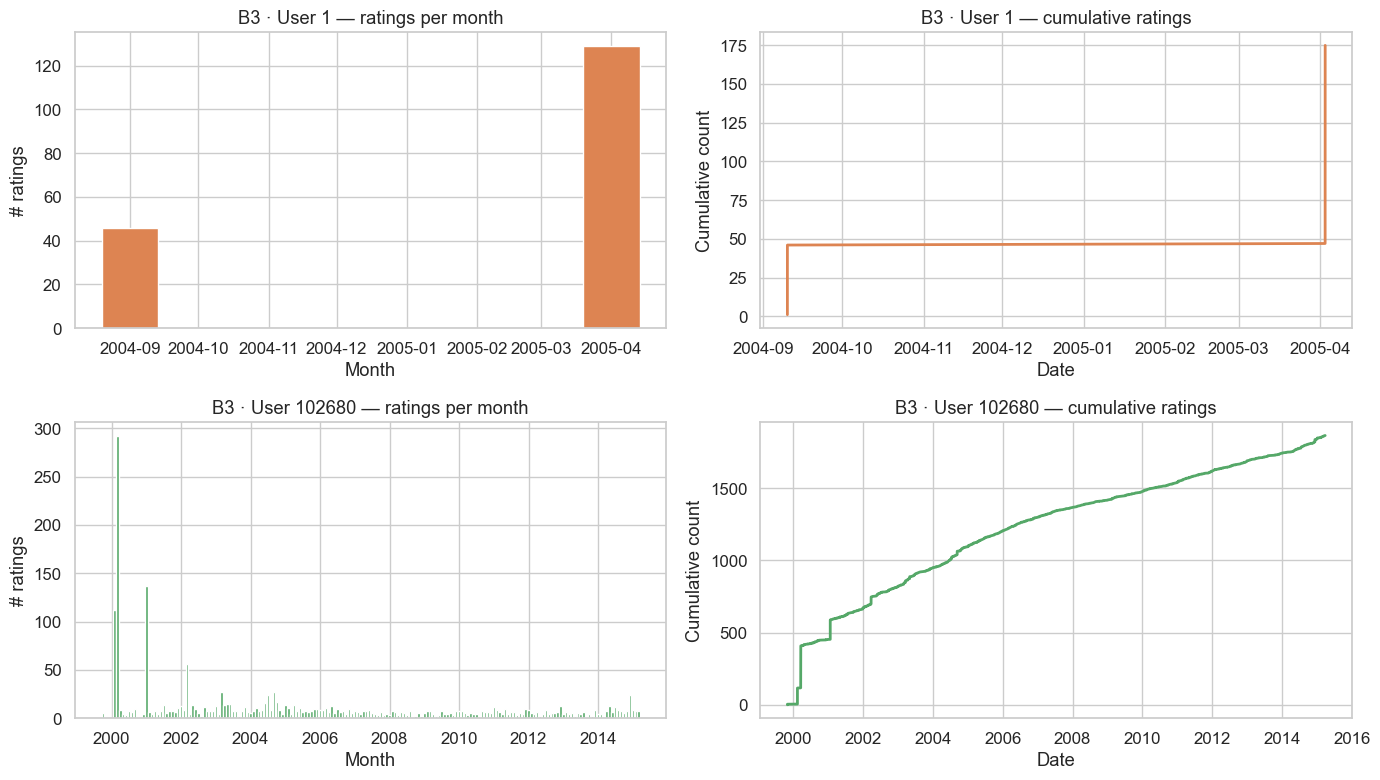

In [13]:
def temporal_profile(user_df, uid, color):
    ts = user_df["timestamp"].dropna().sort_values()
    span_days = (ts.max() - ts.min()).days
    print(f"\nUser {uid}:")
    print(f"  First rating : {ts.min().date()}")
    print(f"  Last  rating : {ts.max().date()}")
    print(f"  Span         : {span_days} days ({span_days/365:.1f} years)")
    print(f"  Avg rate     : {len(user_df)/max(span_days,1)*30:.1f} ratings/month")

temporal_profile(u1, 1, COLORS["u1"])
temporal_profile(u2, 102680, COLORS["u102680"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (user_df, uid, color) in enumerate([
    (u1, 1, COLORS["u1"]),
    (u2, 102680, COLORS["u102680"]),
]):
    ts = user_df.copy()
    ts["month"] = ts["timestamp"].dt.to_period("M")
    monthly = ts.groupby("month")["rating"].count().reset_index()
    monthly["month_dt"] = monthly["month"].dt.to_timestamp()

    # left: ratings per month
    ax = axes[row_idx, 0]
    ax.bar(monthly["month_dt"], monthly["rating"], color=color, width=25)
    ax.set_title(f"B3 · User {uid} — ratings per month")
    ax.set_xlabel("Month")
    ax.set_ylabel("# ratings")

    # right: cumulative ratings over time
    ax2 = axes[row_idx, 1]
    ts_sorted = user_df["timestamp"].dropna().sort_values()
    ax2.plot(ts_sorted.values, np.arange(1, len(ts_sorted)+1), color=color, lw=2)
    ax2.set_title(f"B3 · User {uid} — cumulative ratings")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Cumulative count")

plt.tight_layout()
plt.show()

## C4 · Popularity Profile

Do each user rate mainstream blockbusters or niche films?  
Measure by the number of other users who also rated each movie.

,User 1,User 102680
Mean popularity,14371.8,4556.3
Median popularity,9564.0,1172.0
% rated by < 10 others,0.0,2.2


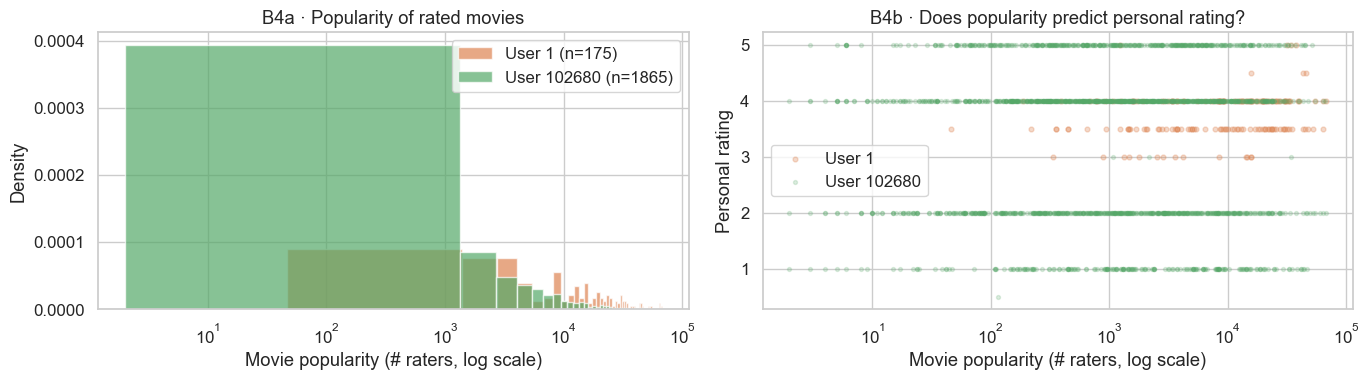

In [14]:
# attach popularity (# raters) to each rating
u1_pop  = u1.merge(movie_counts.rename("popularity"), left_on="movieId", right_index=True)
u2_pop  = u2.merge(movie_counts.rename("popularity"), left_on="movieId", right_index=True)

stats_b4 = pd.DataFrame({
    "User 1"     : [u1_pop["popularity"].mean(), u1_pop["popularity"].median(),
                    (u1_pop["popularity"] < 10).mean()*100],
    "User 102680": [u2_pop["popularity"].mean(), u2_pop["popularity"].median(),
                    (u2_pop["popularity"] < 10).mean()*100],
}, index=["Mean popularity", "Median popularity", "% rated by < 10 others"])
display(stats_b4.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: distribution of popularity scores for rated movies
ax = axes[0]
ax.hist(u1_pop["popularity"],  bins=50, alpha=0.7, color=COLORS["u1"],
        label=f"User 1 (n={len(u1_pop)})", density=True)
ax.hist(u2_pop["popularity"],  bins=50, alpha=0.7, color=COLORS["u102680"],
        label=f"User 102680 (n={len(u2_pop)})", density=True)
ax.set_xscale("log")
ax.set_xlabel("Movie popularity (# raters, log scale)")
ax.set_ylabel("Density")
ax.set_title("B4a · Popularity of rated movies")
ax.legend()

# right: popularity vs personal rating (scatter)
ax2 = axes[1]
ax2.scatter(u1_pop["popularity"],  u1_pop["rating"],  alpha=0.3, s=12,
            color=COLORS["u1"],      label="User 1")
ax2.scatter(u2_pop["popularity"],  u2_pop["rating"],  alpha=0.2, s=8,
            color=COLORS["u102680"], label="User 102680")
ax2.set_xscale("log")
ax2.set_xlabel("Movie popularity (# raters, log scale)")
ax2.set_ylabel("Personal rating")
ax2.set_title("B4b · Does popularity predict personal rating?")
ax2.legend()

plt.tight_layout()
plt.show()

## C5 · Rating Calibration vs Global

For movies both a user and the global crowd have rated,  
does the user rate higher or lower than the crowd?  
This quantifies personal bias — the core of RBM personalization.

Rating delta = user rating − global mean for that movie


,User 1,User 102680
Mean delta,0.114,-0.156
Median delta,0.117,0.231
% rated above global mean,58.286,58.177
Std dev of delta,0.532,1.300


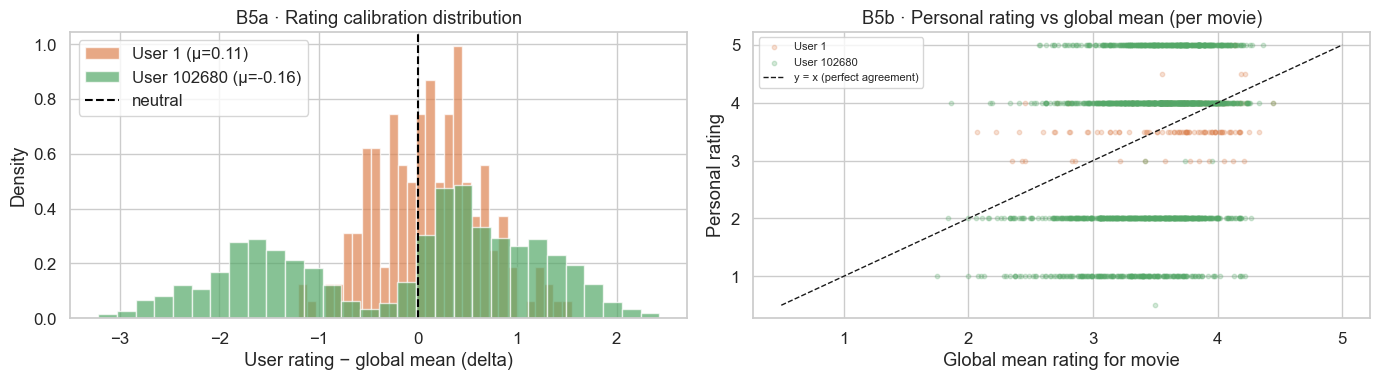

In [15]:
# global mean per movie
global_movie_mean = df.groupby("movieId")["rating"].mean().rename("global_mean")

def calibration_df(user_df):
    d = user_df[["movieId", "rating"]].merge(
        global_movie_mean, left_on="movieId", right_index=True
    )
    d["delta"] = d["rating"] - d["global_mean"]
    return d

cal1 = calibration_df(u1)
cal2 = calibration_df(u2)

print("Rating delta = user rating − global mean for that movie")
cal_stats = pd.DataFrame({
    "User 1"     : [cal1["delta"].mean(), cal1["delta"].median(),
                    (cal1["delta"] > 0).mean()*100, cal1["delta"].std()],
    "User 102680": [cal2["delta"].mean(), cal2["delta"].median(),
                    (cal2["delta"] > 0).mean()*100, cal2["delta"].std()],
}, index=["Mean delta", "Median delta", "% rated above global mean", "Std dev of delta"])
display(cal_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: delta histogram
ax = axes[0]
ax.hist(cal1["delta"], bins=30, alpha=0.7, color=COLORS["u1"],
        label=f"User 1 (μ={cal1['delta'].mean():.2f})", density=True)
ax.hist(cal2["delta"], bins=30, alpha=0.7, color=COLORS["u102680"],
        label=f"User 102680 (μ={cal2['delta'].mean():.2f})", density=True)
ax.axvline(0, color="black", lw=1.5, linestyle="--", label="neutral")
ax.set_xlabel("User rating − global mean (delta)")
ax.set_ylabel("Density")
ax.set_title("B5a · Rating calibration distribution")
ax.legend()

# right: scatter user rating vs global mean
ax2 = axes[1]
for cal, color, label in [
    (cal1, COLORS["u1"], "User 1"),
    (cal2, COLORS["u102680"], "User 102680"),
]:
    ax2.scatter(cal["global_mean"], cal["rating"], alpha=0.25, s=10, color=color, label=label)
ax2.plot([0.5, 5], [0.5, 5], "k--", lw=1, label="y = x (perfect agreement)")
ax2.set_xlabel("Global mean rating for movie")
ax2.set_ylabel("Personal rating")
ax2.set_title("B5b · Personal rating vs global mean (per movie)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Summary — User Profile Comparison

A consolidated view of what we learned about User 1 vs User 102680.

In [16]:
summary_final = pd.DataFrame({
    "Dimension": [
        "# rated movies",
        "# unseen movies",
        "Coverage of full catalog",
        "Activity percentile",
        "Mean rating",
        "Rating std dev",
        "Half-star usage",
        "Median movie popularity",
        "Rating delta vs global (mean)",
        "% rated above global mean",
    ],
    "User 1": [
        len(u1),
        TOTAL_MOVIES - len(u1),
        f"{len(u1)/TOTAL_MOVIES*100:.2f}%",
        f"{(user_counts < len(u1)).mean()*100:.1f}th pct",
        f"{u1['rating'].mean():.2f}",
        f"{u1['rating'].std():.2f}",
        f"{(u1['rating'] % 1 != 0).mean()*100:.1f}%",
        f"{u1_pop['popularity'].median():.0f}",
        f"{cal1['delta'].mean():.3f}",
        f"{(cal1['delta'] > 0).mean()*100:.1f}%",
    ],
    "User 102680": [
        len(u2),
        TOTAL_MOVIES - len(u2),
        f"{len(u2)/TOTAL_MOVIES*100:.2f}%",
        f"{(user_counts < len(u2)).mean()*100:.1f}th pct",
        f"{u2['rating'].mean():.2f}",
        f"{u2['rating'].std():.2f}",
        f"{(u2['rating'] % 1 != 0).mean()*100:.1f}%",
        f"{u2_pop['popularity'].median():.0f}",
        f"{cal2['delta'].mean():.3f}",
        f"{(cal2['delta'] > 0).mean()*100:.1f}%",
    ],
})
display(summary_final.set_index("Dimension"))

print("""
Key takeaways for RBM modeling
────────────────────────────────────────────────────────────────────────────
• Both users have rated << 10% of the catalog → RBM must reconstruct from
  very sparse visible vectors.
• Users differ in activity level, rating style, and popularity preference
  → identical RBM weights would produce very different hidden activations.
• Rating calibration (delta) reveals personal bias beyond the global mean,
  which is exactly what RBM hidden units are expected to capture.
""")

,User 1,User 102680
Dimension,,
# rated movies,175,1865
# unseen movies,26569,24879
Coverage of full catalog,0.65%,6.97%
Activity percentile,77.9th pct,99.8th pct
Mean rating,3.74,3.32
Rating std dev,0.38,1.36
Half-star usage,43.4%,0.1%
Median movie popularity,9564,1172
Rating delta vs global (mean),0.114,-0.156



Key takeaways for RBM modeling
────────────────────────────────────────────────────────────────────────────
• Both users have rated << 10% of the catalog → RBM must reconstruct from
  very sparse visible vectors.
• Users differ in activity level, rating style, and popularity preference
  → identical RBM weights would produce very different hidden activations.
• Rating calibration (delta) reveals personal bias beyond the global mean,
  which is exactly what RBM hidden units are expected to capture.

